# Restore Model and Run New Trials

This notebook restores a trained evidence accumulation model from `model_spec.json` + TensorFlow checkpoint, then runs **inference only** on configurable trial scenarios.

No optimizer or training step is created or executed in this notebook.

## 1) Set Up Notebook Environment and Imports

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow.compat.v1 as tf

tf.disable_v2_behavior()

# Resolve repository paths from current notebook location.
NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR.parent
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

print('Notebook directory:', NB_DIR)
print('Repo root:', REPO_ROOT)

Instructions for updating:
non-resource variables are not supported in the long term
Notebook directory: /home/nuttidalab/Documents/renee/eligibility_propagation/Figure_3_and_S7_e_prop_tutorials
Repo root: /home/nuttidalab/Documents/renee/eligibility_propagation


## 2) Import Project Functions from the Repository

In [2]:
from restore_evidence_accumulation_model import (
    load_model_spec,
    build_graph,
    get_data_dict,
    get_trial_scenarios,
)

print('Imported functions:')
print(' -', load_model_spec)
print(' -', build_graph)
print(' -', get_data_dict)
print(' -', get_trial_scenarios)

The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
  * https://github.com/tensorflow/io (for I/O related ops)
If you depend on functionality not listed there, please file an issue.

Imported functions:
 - <function load_model_spec at 0x74c588f8e8c8>
 - <function build_graph at 0x74c56bf4cae8>
 - <function get_data_dict at 0x74c56bf4c9d8>
 - <function get_trial_scenarios at 0x74c56bf4ca60>


## 3) Load Configuration and Model Checkpoint

In [5]:
# Pick your saved run folder manually, or leave AUTO to use the newest.
RUNS_ROOT = NB_DIR / 'results'
MODEL_SPEC_PATH = None  # Example: NB_DIR / 'results' / 'evidence_accumulation_eprop_true_20260401_120000' / 'model_spec.json'

if MODEL_SPEC_PATH is None:
    spec_paths = sorted(RUNS_ROOT.glob('evidence_accumulation_eprop_*/model_spec.json'))
    if not spec_paths:
        raise FileNotFoundError(f'No model_spec.json found under {RUNS_ROOT}')
    MODEL_SPEC_PATH = spec_paths[-1]

MODEL_SPEC_PATH = Path(MODEL_SPEC_PATH)
spec = load_model_spec(str(MODEL_SPEC_PATH))

N_BATCH = 64
saver, ep = build_graph(spec, batch_size=N_BATCH)

sess = tf.Session()
sess.run(tf.global_variables_initializer())
saver.restore(sess, spec['checkpoint_prefix'])

print('Loaded model spec:', MODEL_SPEC_PATH)
print('Checkpoint prefix:', spec['checkpoint_prefix'])
print('eprop mode from spec:', spec.get('eprop', False))


Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Instructions for updating:
Please use `keras.layers.RNN(cell)`, which is equivalent to this API
INFO:tensorflow:Restoring parameters from results/evidence_accumulation_eprop_true_20260401_183358/model.ckpt
Loaded model spec: /home/nuttidalab/Documents/renee/eligibility_propagation/Figure_3_and_S7_e_prop_tutorials/results/evidence_accumulation_eprop_true_20260401_183358/model_spec.json
Checkpoint prefix: results/evidence_accumulation_eprop_true_20260401_183358/model.ckpt
eprop mode from spec: True


## 4) Prepare Trial Inputs for Inference

In [6]:
# Start from default scenarios from the script, then edit/add your own here.
trial_scenarios = get_trial_scenarios(spec)

# Add an explicit batch size per scenario to leverage dynamic-batch placeholders.
for s in trial_scenarios:
    s['batch_size'] = 64

# Example custom scenario to modify difficulty.
trial_scenarios.append({
    'name': 'custom_long_gap',
    'p_group': 0.4,
    'n_cues': 9,
    't_cue': 100,
    't_cue_spacing': 220,
    'recall_duration': 180,
    'n_input_symbols': 4,
    'input_f0': float(spec.get('input_f0', 40.0 / 1000.0)),
    'seq_len': None,
    'batch_size': 32,
})

# Example tiny-batch scenario for quick sanity checks.
trial_scenarios.append({
    'name': 'single_trial_mode',
    'p_group': 0.3,
    'n_cues': 7,
    't_cue': 100,
    't_cue_spacing': int(spec.get('t_cue_spacing', 150)),
    'recall_duration': 150,
    'n_input_symbols': 4,
    'input_f0': float(spec.get('input_f0', 40.0 / 1000.0)),
    'seq_len': None,
    'batch_size': 1,
})

print('Scenarios to run:', [(s['name'], s['batch_size']) for s in trial_scenarios])

# Build one feed dict for sanity checks.
scenario = trial_scenarios[0]
feed = get_data_dict(
    batch_size=int(scenario['batch_size']),
    input_spikes_ph=ep['input_spikes'],
    input_nums_ph=ep['input_nums'],
    target_nums_ph=ep['target_nums'],
    n_in=ep['n_in'],
    t_cue_spacing=scenario['t_cue_spacing'],
    input_f0=scenario['input_f0'],
    p_group=scenario['p_group'],
    n_cues=scenario['n_cues'],
    t_cue=scenario['t_cue'],
    recall_duration=scenario['recall_duration'],
    n_input_symbols=scenario['n_input_symbols'],
    seq_len_override=scenario['seq_len'],
)

print('Input shape:', feed[ep['input_spikes']].shape)
print('Target shape:', feed[ep['target_nums']].shape)
print('Input dtype:', feed[ep['input_spikes']].dtype)

Scenarios to run: [('baseline', 64), ('ambiguous_balance', 64), ('long_memory', 64), ('custom_long_gap', 32), ('single_trial_mode', 1)]
Input shape: (64, 2250, 40)
Target shape: (64, 2250)
Input dtype: bool


In [12]:
target_nums.shape

(64, 2250)

In [16]:
input_nums.shape

(1, 2250)

In [17]:
ep

{'input_spikes': <tf.Tensor 'InputSpikes:0' shape=(?, ?, 40) dtype=float32>,
 'input_nums': <tf.Tensor 'InputNums:0' shape=(?, ?) dtype=float32>,
 'target_nums': <tf.Tensor 'TargetNums:0' shape=(?, ?) dtype=int64>,
 'z': <tf.Tensor 'rnn/transpose_1:0' shape=(?, ?, 100) dtype=float32>,
 'y_predict': <tf.Tensor 'ArgMax:0' shape=(?,) dtype=int64>,
 'accuracy': <tf.Tensor 'Mean_1:0' shape=() dtype=float32>,
 't_cue_spacing': 150,
 'input_f0': 0.04,
 'n_in': 40}

In [18]:
feed.keys()

dict_keys([<tf.Tensor 'InputSpikes:0' shape=(?, ?, 40) dtype=float32>, <tf.Tensor 'InputNums:0' shape=(?, ?) dtype=float32>, <tf.Tensor 'TargetNums:0' shape=(?, ?) dtype=int64>])

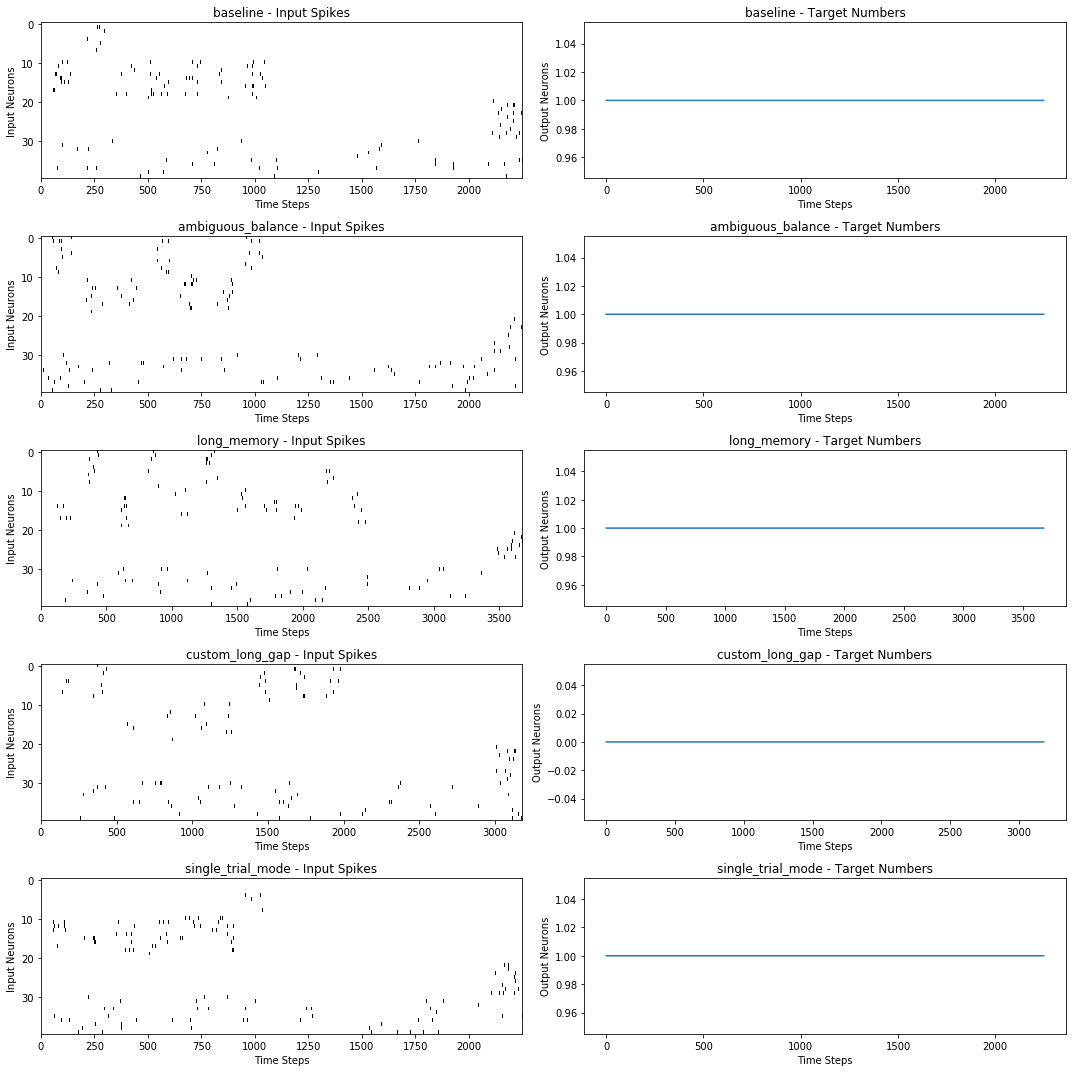

In [ ]:
# plot stimuli and targets for the first trial in each scenario

fig, axes = plt.subplots(len(trial_scenarios), 2, figsize=(15, 3 * len(trial_scenarios)))
for i, scenario in enumerate(trial_scenarios):
    feed = get_data_dict(
        batch_size=int(scenario['batch_size']),
        input_spikes_ph=ep['input_spikes'],
        input_nums_ph=ep['input_nums'],
        target_nums_ph=ep['target_nums'],
        n_in=ep['n_in'],
        t_cue_spacing=scenario['t_cue_spacing'],
        input_f0=scenario['input_f0'],
        p_group=scenario['p_group'],
        n_cues=scenario['n_cues'],
        t_cue=scenario['t_cue'],
        recall_duration=scenario['recall_duration'],
        n_input_symbols=scenario['n_input_symbols'],
        seq_len_override=scenario['seq_len'],
    )
    input_spikes = feed[ep['input_spikes']]
    target_nums = feed[ep['target_nums']]
    
    # Plot the first trial's input spikes
    axes[i, 0].imshow(input_spikes[0].T, aspect='auto', cmap='gray_r')
    axes[i, 0].set_title(f"{scenario['name']} - Input Spikes")
    axes[i, 0].set_xlabel('Time Steps')
    axes[i, 0].set_ylabel('Input Neurons')
    
    # Plot the first trial's target numbers
    axes[i, 1].plot(target_nums[0].T)
    axes[i, 1].set_title(f"{scenario['name']} - Target Numbers")
    axes[i, 1].set_xlabel('Time Steps')
    axes[i, 1].set_ylabel('Output Neurons')

plt.tight_layout()
plt.show()

## 5) Run Single-Trial Inference

Single-trial true label: 1
Single-trial predicted: 1
Spike tensor shape: (1, 2250, 100)


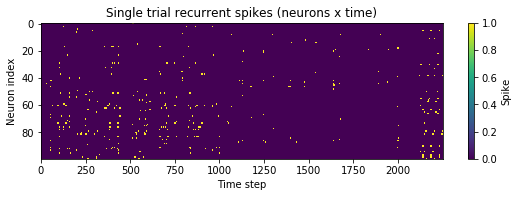

In [7]:
# Use a true single-example feed without slicing from a larger batch.
single_scenario = {
    'p_group': 0.3,
    'n_cues': 7,
    't_cue': 100,
    't_cue_spacing': int(spec.get('t_cue_spacing', 150)),
    'recall_duration': 150,
    'n_input_symbols': 4,
    'input_f0': float(spec.get('input_f0', 40.0 / 1000.0)),
    'seq_len': None,
}

single_feed = get_data_dict(
    batch_size=1,
    input_spikes_ph=ep['input_spikes'],
    input_nums_ph=ep['input_nums'],
    target_nums_ph=ep['target_nums'],
    n_in=ep['n_in'],
    t_cue_spacing=single_scenario['t_cue_spacing'],
    input_f0=single_scenario['input_f0'],
    p_group=single_scenario['p_group'],
    n_cues=single_scenario['n_cues'],
    t_cue=single_scenario['t_cue'],
    recall_duration=single_scenario['recall_duration'],
    n_input_symbols=single_scenario['n_input_symbols'],
    seq_len_override=single_scenario['seq_len'],
)

pred, z_vals = sess.run([ep['y_predict'], ep['z']], feed_dict=single_feed)
true_label = int(single_feed[ep['target_nums']][0, -1])

print('Single-trial true label:', true_label)
print('Single-trial predicted:', int(pred[0]))
print('Spike tensor shape:', z_vals.shape)

plt.figure(figsize=(9, 2.5))
plt.imshow(z_vals[0].T, aspect='auto', interpolation='nearest')
plt.colorbar(label='Spike')
plt.title('Single trial recurrent spikes (neurons x time)')
plt.xlabel('Time step')
plt.ylabel('Neuron index')
plt.show()

## 6) Run Batch Trial Inference

In [8]:
records = []
per_scenario_payload = {}
N_EVAL_BATCHES = 4

for scenario in trial_scenarios:
    payload = {
        'predictions': [],
        'targets': [],
        'spikes': [],
        'input_spikes': [],
    }

    scenario_batch_size = int(scenario.get('batch_size', 64))

    for batch_idx in range(N_EVAL_BATCHES):
        feed = get_data_dict(
            batch_size=scenario_batch_size,
            input_spikes_ph=ep['input_spikes'],
            input_nums_ph=ep['input_nums'],
            target_nums_ph=ep['target_nums'],
            n_in=ep['n_in'],
            t_cue_spacing=scenario['t_cue_spacing'],
            input_f0=scenario['input_f0'],
            p_group=scenario['p_group'],
            n_cues=scenario['n_cues'],
            t_cue=scenario['t_cue'],
            recall_duration=scenario['recall_duration'],
            n_input_symbols=scenario['n_input_symbols'],
            seq_len_override=scenario['seq_len'],
        )

        acc, preds, z_vals, tgt = sess.run(
            [ep['accuracy'], ep['y_predict'], ep['z'], ep['target_nums']],
            feed_dict=feed,
        )

        records.append({
            'scenario': scenario['name'],
            'batch_idx': batch_idx,
            'accuracy': float(acc),
            'n_batch': scenario_batch_size,
            'seq_len': int(feed[ep['input_spikes']].shape[1]),
        })

        payload['predictions'].append(preds)
        payload['targets'].append(tgt[:, -1])
        payload['spikes'].append(z_vals)
        payload['input_spikes'].append(feed[ep['input_spikes']])

    per_scenario_payload[scenario['name']] = payload

results_df = pd.DataFrame(records)
results_df

,scenario,batch_idx,accuracy,n_batch,seq_len
0,baseline,0,0.968750,64,2250
1,baseline,1,0.953125,64,2250
2,baseline,2,0.921875,64,2250
3,baseline,3,0.968750,64,2250
4,ambiguous_balance,0,0.890625,64,2250
5,ambiguous_balance,1,0.859375,64,2250
6,ambiguous_balance,2,0.828125,64,2250
7,ambiguous_balance,3,0.953125,64,2250
8,long_memory,0,0.875000,64,3675
9,long_memory,1,0.906250,64,3675


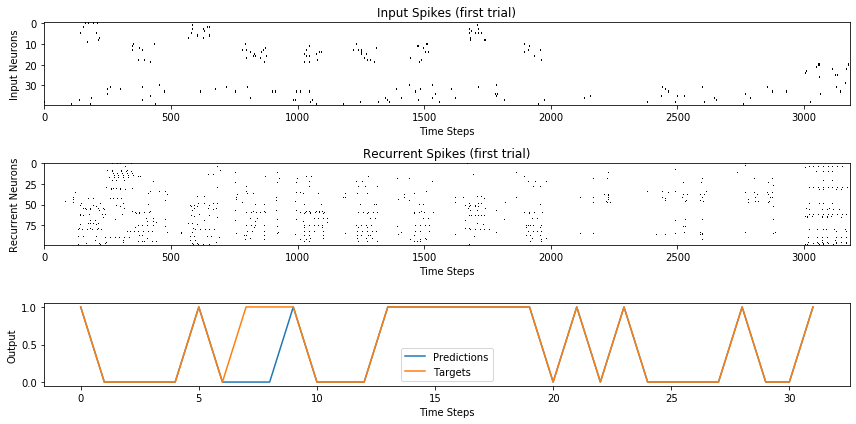

In [21]:
# plot per_scenario_payload, or just payload

predictions = per_scenario_payload['custom_long_gap']['predictions']
targets = per_scenario_payload['custom_long_gap']['targets']
spikes = per_scenario_payload['custom_long_gap']['spikes']
input_spikes = per_scenario_payload['custom_long_gap']['input_spikes']

fig, axes = plt.subplots(3, 1, figsize=(12, 6))
axes[0].imshow(input_spikes[0][0].T, aspect='auto', cmap='gray_r')
axes[0].set_title('Input Spikes (first trial)')
axes[0].set_xlabel('Time Steps')
axes[0].set_ylabel('Input Neurons')
axes[1].imshow(spikes[0][0].T, aspect='auto', cmap='gray_r')
axes[1].set_title('Recurrent Spikes (first trial)')
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Recurrent Neurons')
axes[2].plot(predictions[0], label='Predictions')
axes[2].plot(targets[0], label='Targets')
axes[2].set_xlabel('Time Steps')
axes[2].set_ylabel('Output')
axes[2].legend()
plt.tight_layout()
plt.show()



## 7) Inspect, Visualize, and Save Outputs

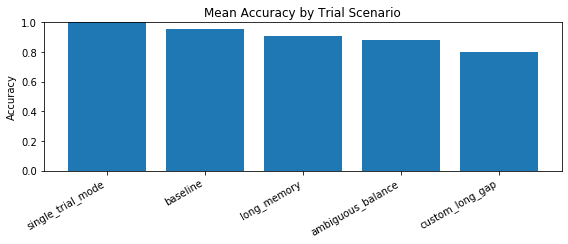

In [9]:
summary_df = (
    results_df.groupby('scenario', as_index=False)
    .agg(mean_accuracy=('accuracy', 'mean'), std_accuracy=('accuracy', 'std'))
    .sort_values('mean_accuracy', ascending=False)
)
summary_df

plt.figure(figsize=(8, 3.5))
plt.bar(summary_df['scenario'], summary_df['mean_accuracy'])
plt.title('Mean Accuracy by Trial Scenario')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
OUT_DIR = NB_DIR / 'notebook_outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

summary_path = OUT_DIR / 'restore_notebook_summary.csv'
summary_json_path = OUT_DIR / 'restore_notebook_summary.json'
summary_df.to_csv(summary_path, index=False)
summary_df.to_json(summary_json_path, orient='records', indent=2)

# Save one NPZ per scenario with predictions/targets/spikes/input spikes.
for scenario_name, payload in per_scenario_payload.items():
    npz_path = OUT_DIR / f'restore_trials_{scenario_name}.npz'
    np.savez_compressed(
        npz_path,
        predictions=np.array(payload['predictions']),
        targets=np.array(payload['targets']),
        spikes=np.array(payload['spikes']),
        input_spikes=np.array(payload['input_spikes']),
    )

print('Saved:', summary_path)
print('Saved:', summary_json_path)
print('Saved scenario NPZ files under:', OUT_DIR)

In [10]:
# Optional cleanup: run when done.
sess.close()